**DS5216 Artificial Intelligence: Programming Assignment II: DTS2433: R. D. Y. vimukthi**

**Notebook 1: Data Preprocessing**


 **Instructions:**
 Please upload the "cricket-player-detection" folder (which is shared in GitHub) before executing the following colab file. The folder contains three sub-folders train, valid, and test, each containing two sub-folders. One for images and one for annotated labels with 5 values for each bounding box (class and 4 corner values of the bounding box)

**Installing required libraries**

In [1]:
!pip -q install ultralytics
!pip -q install opencv-python
!pip -q install tqdm

print("Libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00
Libraries installed successfully.


**Importing libaries**

In [2]:
import os
import cv2
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from google.colab import drive

plt.style.use('ggplot')

**Mounting google drive, verifying GPU,and setting up directory pathways**

In [7]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

if USE_DRIVE:
    DATASET_PATH = "/content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection"
else:
    DATASET_PATH = "/content/cricket-player-detection"

print("Dataset path:", DATASET_PATH)

Dataset path: /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection


In [9]:
import torch

print("="*60)

if torch.cuda.is_available():

    print("GPU detected")
    print(torch.cuda.get_device_name(0))

else:

    print("Running on CPU")

print("="*60)

GPU detected
Tesla T4


In [10]:
splits = ["train", "valid", "test"]

for split in splits:

    print("\nChecking:", split)

    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    print("Images exists :", os.path.exists(image_dir))
    print("Labels exists :", os.path.exists(label_dir))

    print("Images :", len(os.listdir(image_dir)))
    print("Labels :", len(os.listdir(label_dir)))


Checking: train
Images exists : True
Labels exists : True
Images : 215
Labels : 215

Checking: valid
Images exists : True
Labels exists : True
Images : 61
Labels : 61

Checking: test
Images exists : True
Labels exists : True
Images : 31
Labels : 31


**Dataset related Statistics and visualizations**

In [11]:
stats = []

for split in splits:

    image_dir = os.path.join(DATASET_PATH, split, "images")

    jpg = glob.glob(image_dir + "/*.jpg")
    png = glob.glob(image_dir + "/*.png")

    stats.append([
        split,
        len(jpg)+len(png)
    ])

df = pd.DataFrame(
    stats,
    columns=["Dataset Split","Images"]
)

display(df)

,Dataset Split,Images
0,train,215
1,valid,61
2,test,31


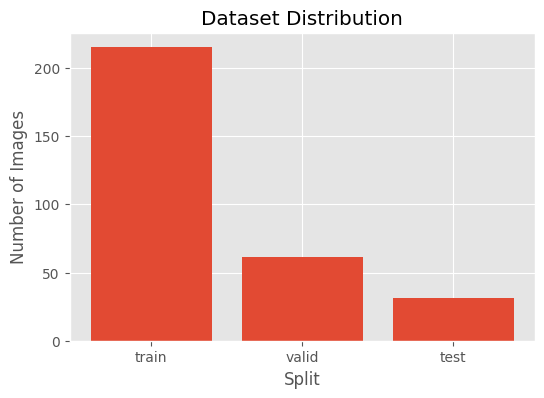

In [13]:
#train, validation, test split = 70:20:10
plt.figure(figsize=(6,4))
plt.bar(df["Dataset Split"], df["Images"])
plt.title("Dataset Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Images")
plt.show()

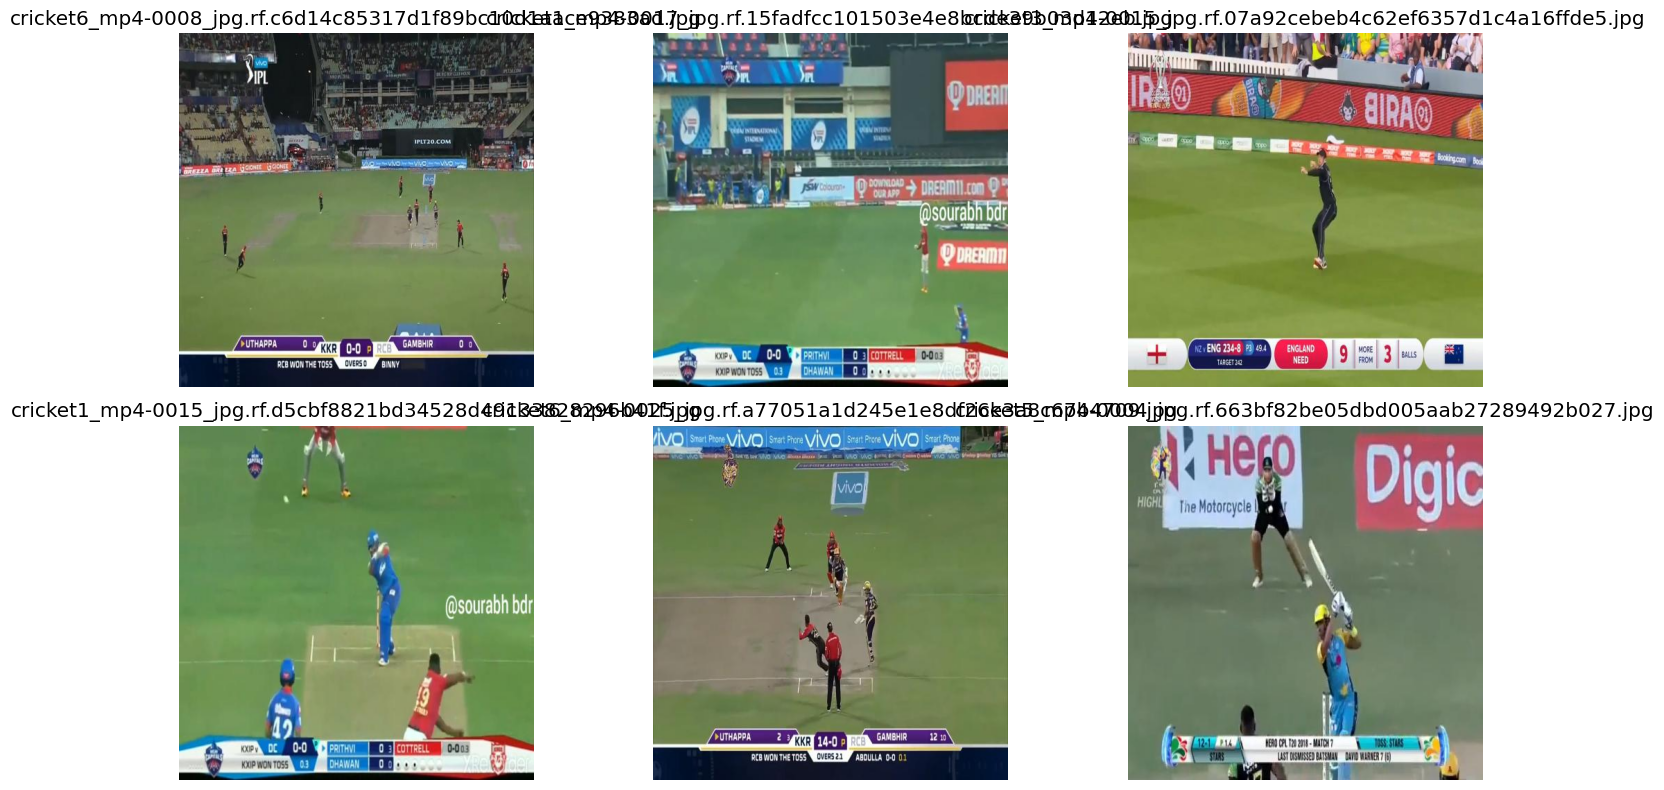

In [14]:
#Displaying random images for verification
train_images = glob.glob(DATASET_PATH+"/train/images/*")
samples = random.sample(train_images,6)
plt.figure(figsize=(15,8))
for i,image_path in enumerate(samples):
    img=cv2.imread(image_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(image_path))
    plt.axis("off")
plt.tight_layout()
plt.show()

**Data Preprocessing**

Converting Polygon Labels to Bounding Boxes.

Why this step was needed? - When generating bounding boxes through RoboFlow, the annotation type was selected as polygon labels which creates a lot of points in addition to the four corners in our usual bounding boxes. To make executions simpler, these were converted back to traditional annotation bounding box labels with just 4 corners.

In [15]:
def polygon_to_bbox(values):
    """
    Convert normalized polygon coordinates to YOLO bounding box.
    values = [class_id, x1, y1, x2, y2, ...]
    """
    cls = int(values[0])
    coords = np.array(values[1:], dtype=float).reshape(-1,2)
    xs = coords[:,0]
    ys = coords[:,1]
    xmin = xs.min()
    xmax = xs.max()
    ymin = ys.min()
    ymax = ys.max()
    x_center = (xmin+xmax)/2
    y_center = (ymin+ymax)/2
    width = xmax-xmin
    height = ymax-ymin
    return f"{cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

Converting all annotations to standard YOLO format with 5 values (class and 4 corners of the bouding box)

In [16]:
for split in splits:

    label_folder = os.path.join(DATASET_PATH, split, "labels")
    files = glob.glob(label_folder+"/*.txt")
    for file in tqdm(files):
        new_lines=[]
        with open(file) as f:
            lines=f.readlines()
        for line in lines:
            values=line.strip().split()
            # already bounding box
            if len(values)==5:
                new_lines.append(line.strip())
            # segmentation polygon
            elif len(values)>5:
                bbox=polygon_to_bbox(values)
                new_lines.append(bbox)

        with open(file,"w") as f:
            for l in new_lines:
                f.write(l+"\n")

100%|██████████| 31/31 [00:09<00:00,  3.23it/s]


In [17]:
#verifying after pre-processing
errors=0
for split in splits:
    labels=glob.glob(DATASET_PATH+"/"+split+"/labels/*.txt")
    for file in labels:
        with open(file) as f:
            for line in f:
                if len(line.split())!=5:
                    errors+=1
print("="*40)
print("Remaining annotation errors :",errors)
print("="*40)

Remaining annotation errors : 0


**Creating the data.yaml file for YOLOv8 model**

In [19]:
%%writefile /content/data.yaml

path: /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection
train: train/images
val: valid/images
test: test/images

names:
  0: player

Writing /content/data.yaml


In [20]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
print("Dataset prepared successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset prepared successfully.
